In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *

In [2]:
path_to_result = "/home/ryan/muography_GNN/trained_model_nophi/"
path_to_stat = "/home/ryan/muography_GNN/preprocessed_data/"

In [3]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz", allow_pickle=True) 

predictions_unnormalized = npz_unpacked['outputs_scaled'].item()
targets_unnormalized = npz_unpacked['targets_scaled'].item()
predictions = npz_unpacked['outputs'].item()
targets = npz_unpacked['targets'].item()
meta = npz_unpacked['meta']

targets_theta = np.degrees(targets_unnormalized["theta"])
# targets_phi = np.degrees(targets_unnormalized["phi"])
predictions_theta = np.degrees(predictions_unnormalized["theta"])
# predictions_phi = np.degrees(predictions_unnormalized["phi"])

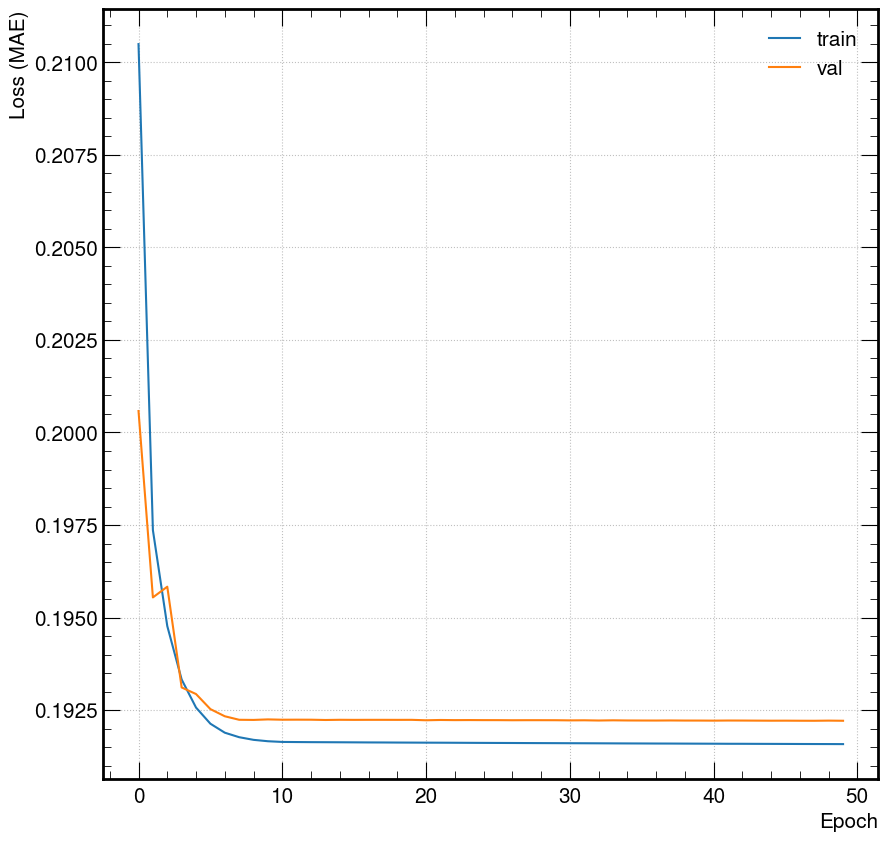

In [4]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()

Text(1, 0, '$\\theta (deg)$')

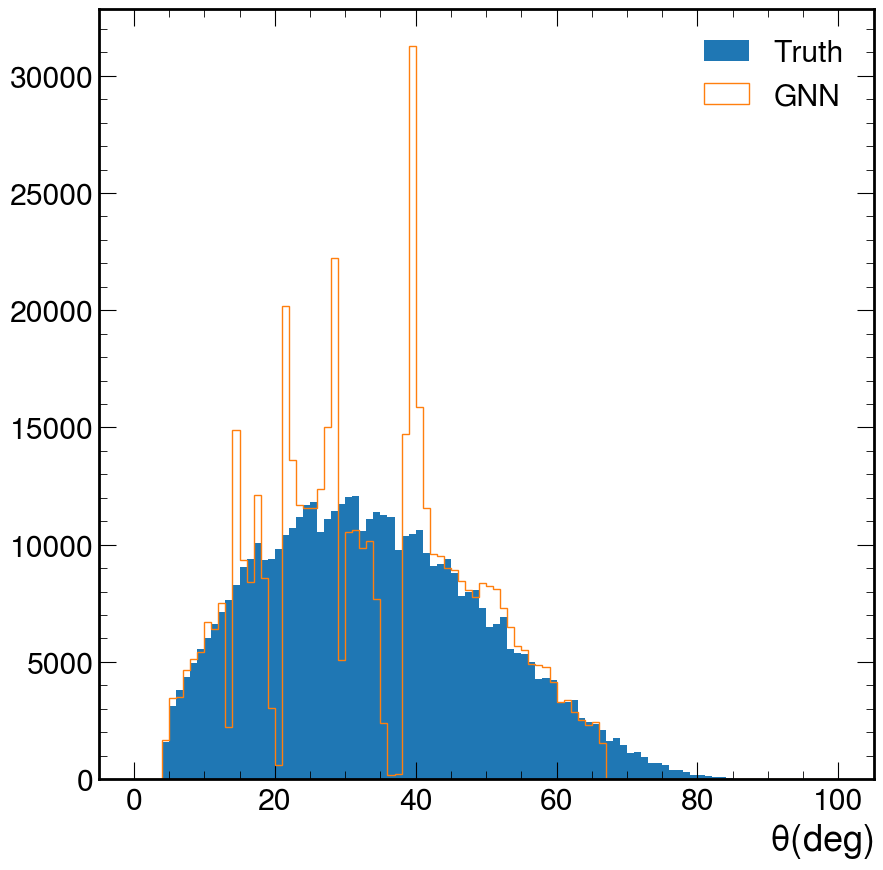

In [5]:
plt.hist(targets_theta, bins=100, range=(0,100), label="Truth")
plt.hist(ak.flatten(predictions_theta), bins=100, range=(0,100), label="GNN", histtype='step')
plt.legend()
plt.xlabel("$\\theta (deg)$")

In [6]:
import uproot
def get_reco(meta_info):
    event_energy_list = np.array([None]*len(meta_info))
    truth_theta_list = np.array([None]*len(meta_info))
    truth_phi_list = np.array([None]*len(meta_info))
    reco_theta_list = np.array([None]*len(meta_info))
    reco_phi_list = np.array([None]*len(meta_info))
    file_and_eventnumber_to_index = {}
    file_names = meta_info[:, 0]
    unique_file_names = np.unique(file_names)
    for unique_name in unique_file_names:
        file_and_eventnumber_to_index[unique_name] = {}
    for i, (file_name, event_number, particle_type) in enumerate(meta_info):
        file_and_eventnumber_to_index[file_name][event_number] = i
    
    for file_name in unique_file_names:
        with uproot.open(file_name+":events") as f:
            mcparticles_arrays = f.arrays(["MCParticles.theta", "MCParticles.phi"])
            reco_arrays = f.arrays(["HcalFarForwardZDCHits.energy", "HcalFarForwardZDCHits.theta", "HcalFarForwardZDCHits.phi", "HcalFarForwardZDCHits.position.y", "HcalFarForwardZDCHits.position.x"])
        theta = ak.flatten(mcparticles_arrays["MCParticles.theta"])
        phi = ak.flatten(mcparticles_arrays["MCParticles.phi"])
        event_energy = ak.sum(reco_arrays["HcalFarForwardZDCHits.energy"], axis=1)
        reco_theta = reco_arrays["HcalFarForwardZDCHits.theta"]
        reco_phi = reco_arrays["HcalFarForwardZDCHits.phi"]
        
        for i, theta_value in enumerate(theta):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                truth_theta_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = theta_value
            else:
                continue
        for i, phi_value in enumerate(phi):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                truth_phi_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = phi_value
            else:
                continue
        for i, energy in enumerate(event_energy):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                event_energy_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = energy
            else:
                continue
        for i, theta_value in enumerate(reco_theta):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                reco_theta_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = theta_value
            else:
                continue
        for i, phi_value in enumerate(reco_phi):
            if f"{i}" in file_and_eventnumber_to_index[file_name]:
                reco_phi_list[file_and_eventnumber_to_index[file_name][f"{i}"]] = phi_value
            else:
                continue
    return truth_theta_list, truth_phi_list, reco_theta_list, reco_phi_list, event_energy_list

In [7]:
import uproot
def save_file_with_gnn(meta_info, GNN_predictions, GNN_truth, data_directory):
    file_and_eventnumber_to_index = {}
    file_names = meta_info[:, 0]
    unique_file_names = np.unique(file_names)
    for unique_name in unique_file_names:
        file_and_eventnumber_to_index[unique_name] = {}
    for i, (file_name, event_number, particle_type) in enumerate(meta_info):
        file_and_eventnumber_to_index[file_name][event_number] = i
    
    for file_name in unique_file_names:
        with uproot.open(file_name+":events") as f:
            file_arrays = f.arrays()
        fields_to_save = [field for field in file_arrays.fields if 'nHcalFarForwardZDCHits' not in field and 'nMCParticles' not in field]
        output_data = {}
        for field in fields_to_save:
            output_data[field] = file_arrays[field]
        num_events = len(file_arrays)
        gnn_preds, gnn_truths = [], []
        for event_number in range(num_events):
            # Find the global index for this (file, event_number)
            idx = file_and_eventnumber_to_index[file_name].get(f"{int(event_number)}", None)
            if idx is None:
                gnn_preds.append(None)
                gnn_truths.append(None)# skip if event isn't in meta_info
            
            gnn_preds.append(GNN_predictions[idx])
            gnn_truths.append(GNN_truth[idx])
        output_data["GNN_theta"] = ak.Array(gnn_preds)
        # output_data["GNN_true_theta"] = ak.Array(gnn_truths)
        base_name = os.path.basename(file_name) 
        base_name = base_name.replace(".root", "") 
        if not os.path.exists(data_directory):
            os.makedirs(data_directory)
        save_path = os.path.join(data_directory, f"{base_name}_withGNN.root")
        with uproot.recreate(save_path) as fout:
            fout["events"] = output_data

In [8]:
save_file_with_gnn(
    meta,
    ak.flatten(predictions_theta),
    targets_theta,
    "/media/miguel/Elements_2024/AI_data/datasets/muography_GNN_data/data_with_GNN_output/")

In [9]:
truth_theta, truth_phi, reco_theta, reco_phi, reco_energy = get_reco(meta)

Text(1, 0, '$\\theta$ (deg)')

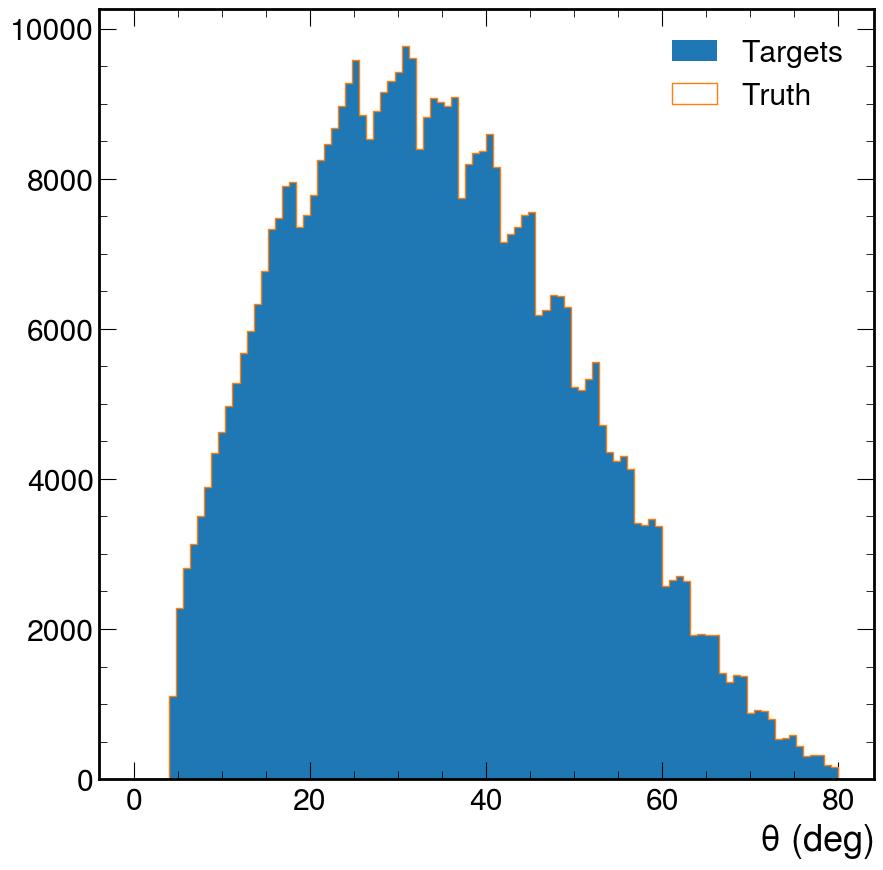

In [10]:
plt.hist(targets_theta, bins=100, range=(0,80), label="Targets")
plt.hist(truth_theta, bins=100, range=(0,80),label="Truth", histtype='step')
plt.legend()
plt.xlabel("$\\theta$ (deg)")

In [11]:
# plt.hist(targets_phi, bins=100, label="Targets")
# plt.hist(truth_phi, bins=100, label="Truth", histtype='step')
# plt.legend()
# plt.xlabel("$\phi$ (deg)")

In [12]:
theta_bins =  np.logspace(1,1.8,10)
theta_bin_centers = (theta_bins[:-1] + theta_bins[1:]) / 2

Text(0, 1, 'Summed cell energies (MeV)')

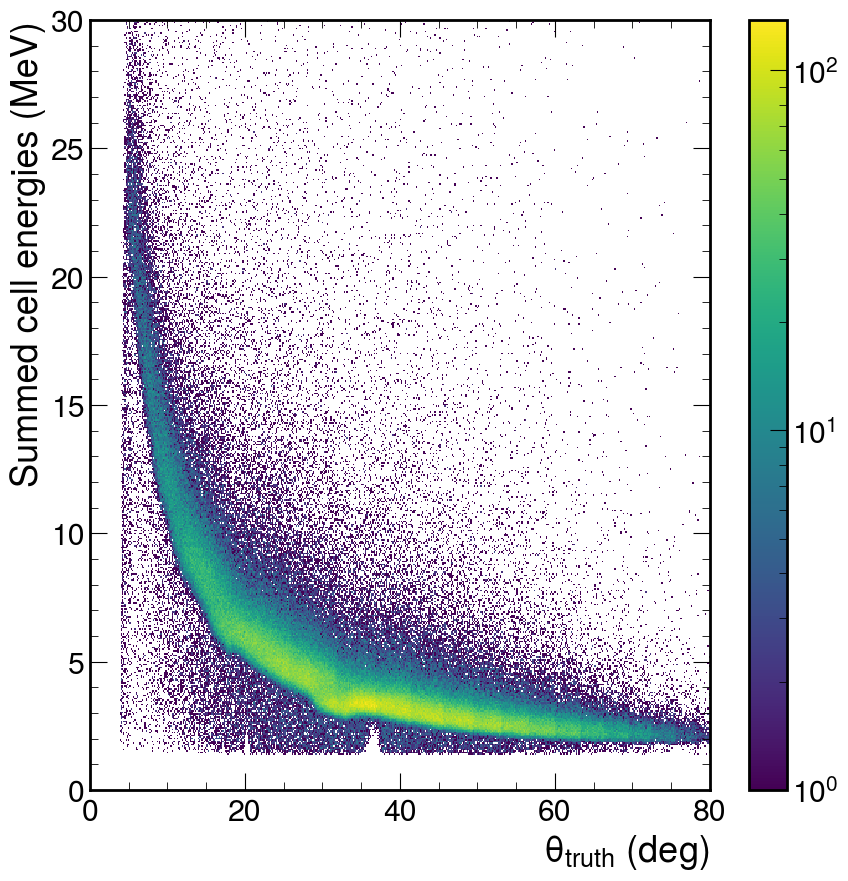

In [23]:
import matplotlib.colors as colors
plt.hist2d(np.array(truth_theta), np.array(reco_energy)*1000, bins=500, range= ((0,80), (0, 30)), norm=colors.LogNorm())
plt.colorbar()
plt.xlabel("$\\theta_{truth}$ (deg)")
plt.ylabel("Summed cell energies (MeV)")

Text(0, 1, '$\\theta_{GNN}$ (deg)')

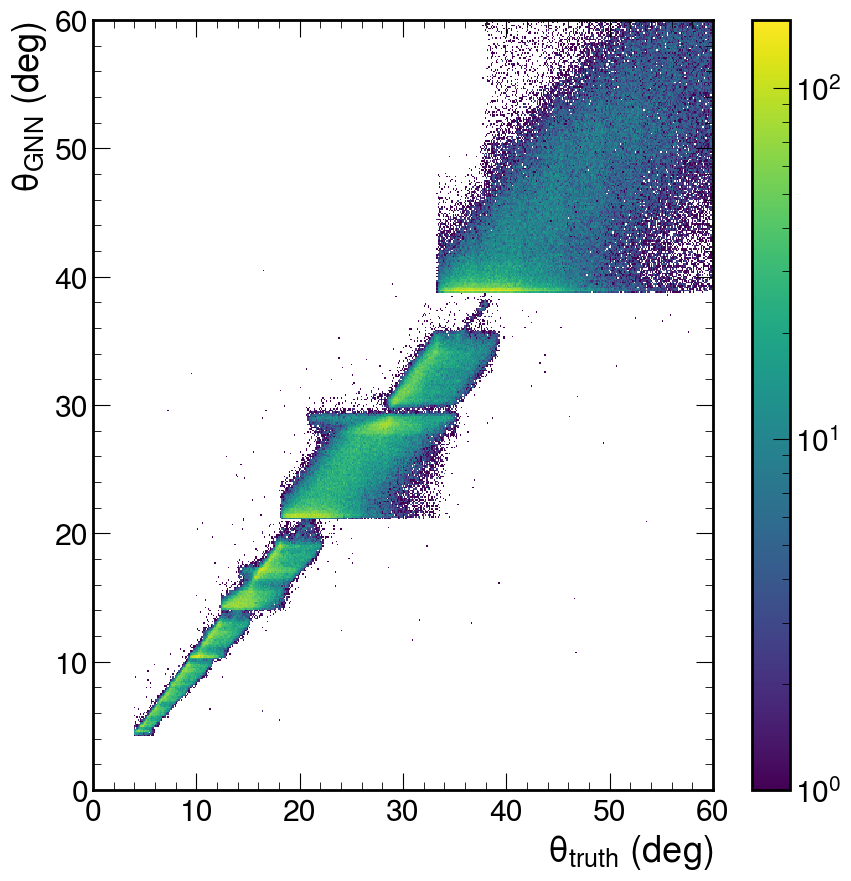

In [24]:
plt.hist2d(np.array(targets_theta), np.array(ak.flatten(predictions_theta)), bins=500, range= ((0,60), (0, 60)), norm=colors.LogNorm())
plt.colorbar()
plt.xlabel("$\\theta_{truth}$ (deg)")
plt.ylabel("$\\theta_{GNN}$ (deg)")

Text(1, 0, '$\\theta (deg)$')

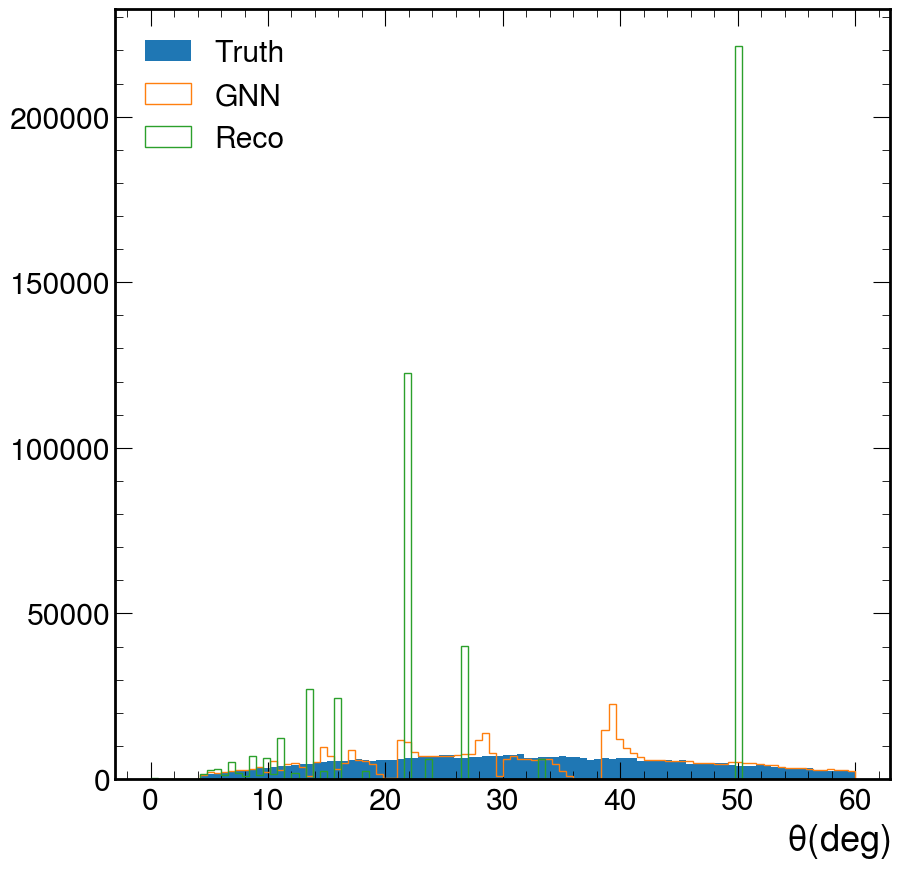

In [15]:
plt.hist(targets_theta, bins=100, range=(0,60), label="Truth")
plt.hist(predictions_theta, bins=100, range=(0,60),label="GNN", histtype='step')
plt.hist(reco_theta, bins=100,range=(0,60),label="Reco", histtype='step')
plt.legend()
plt.xlabel("$\\theta (deg)$")

Text(0.5, 1.0, "Jay's binning: np.logspace(1,1.8,10)")

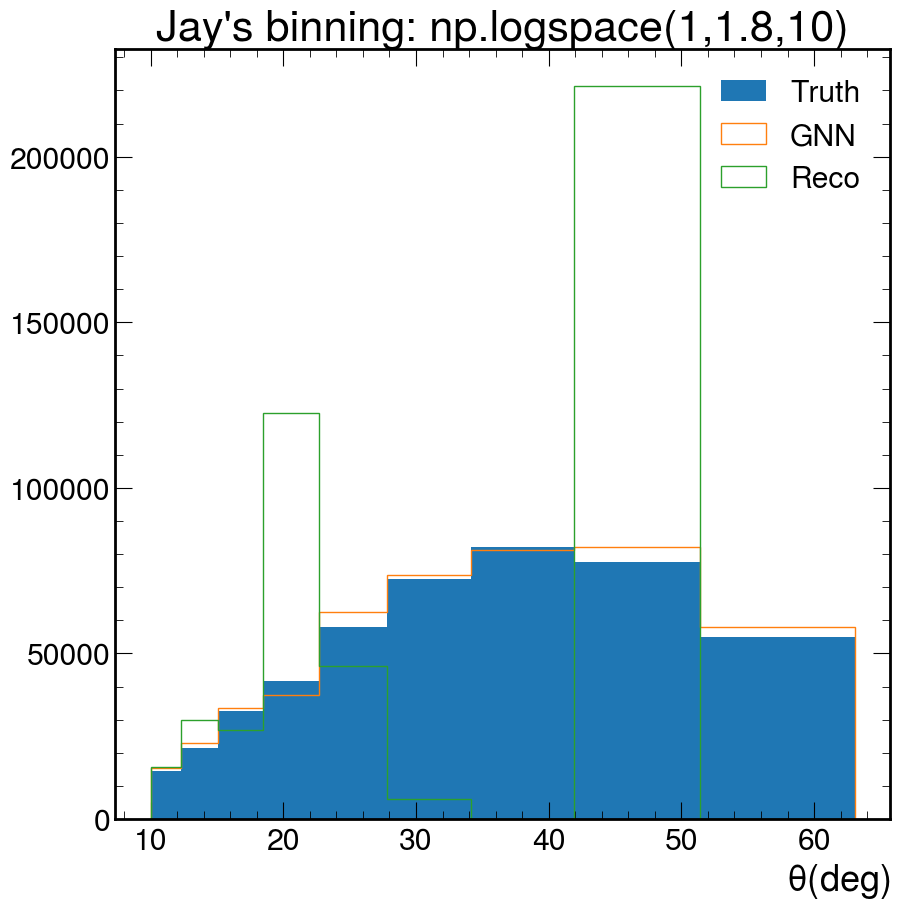

In [16]:
plt.hist(targets_theta, bins=theta_bins, label="Truth")
plt.hist(predictions_theta, bins=theta_bins,label="GNN", histtype='step')
plt.hist(reco_theta, bins=theta_bins,label="Reco", histtype='step')
plt.legend()
plt.xlabel("$\\theta (deg)$")
plt.title("Jay's binning: np.logspace(1,1.8,10)")

In [17]:
# plt.hist(targets_phi, bins=36, label="Truth")
# plt.hist(predictions_phi, bins=36, label="GNN", histtype='step')
# plt.hist(reco_phi, bins=36, label="Reco", histtype='step')
# plt.legend()
# plt.xlabel("$\\phi (deg)$")
# plt.title("Before np.mod")

In [18]:
# wrapped_predictions_phi = np.mod(predictions_phi, 360)
# wrapped_targets_phi = np.mod(targets_phi, 360)
# wrapped_reco_phi = np.mod(reco_phi, 360)
# plt.hist(wrapped_targets_phi, bins=36, label="Truth")
# plt.hist(wrapped_predictions_phi, bins=36, label="GNN", histtype='step')
# # plt.hist(wrapped_reco_phi, bins=36, label="Reco", histtype='step')
# plt.legend()
# plt.xlabel("$\\phi (deg)$")
# plt.title("After np.mod")

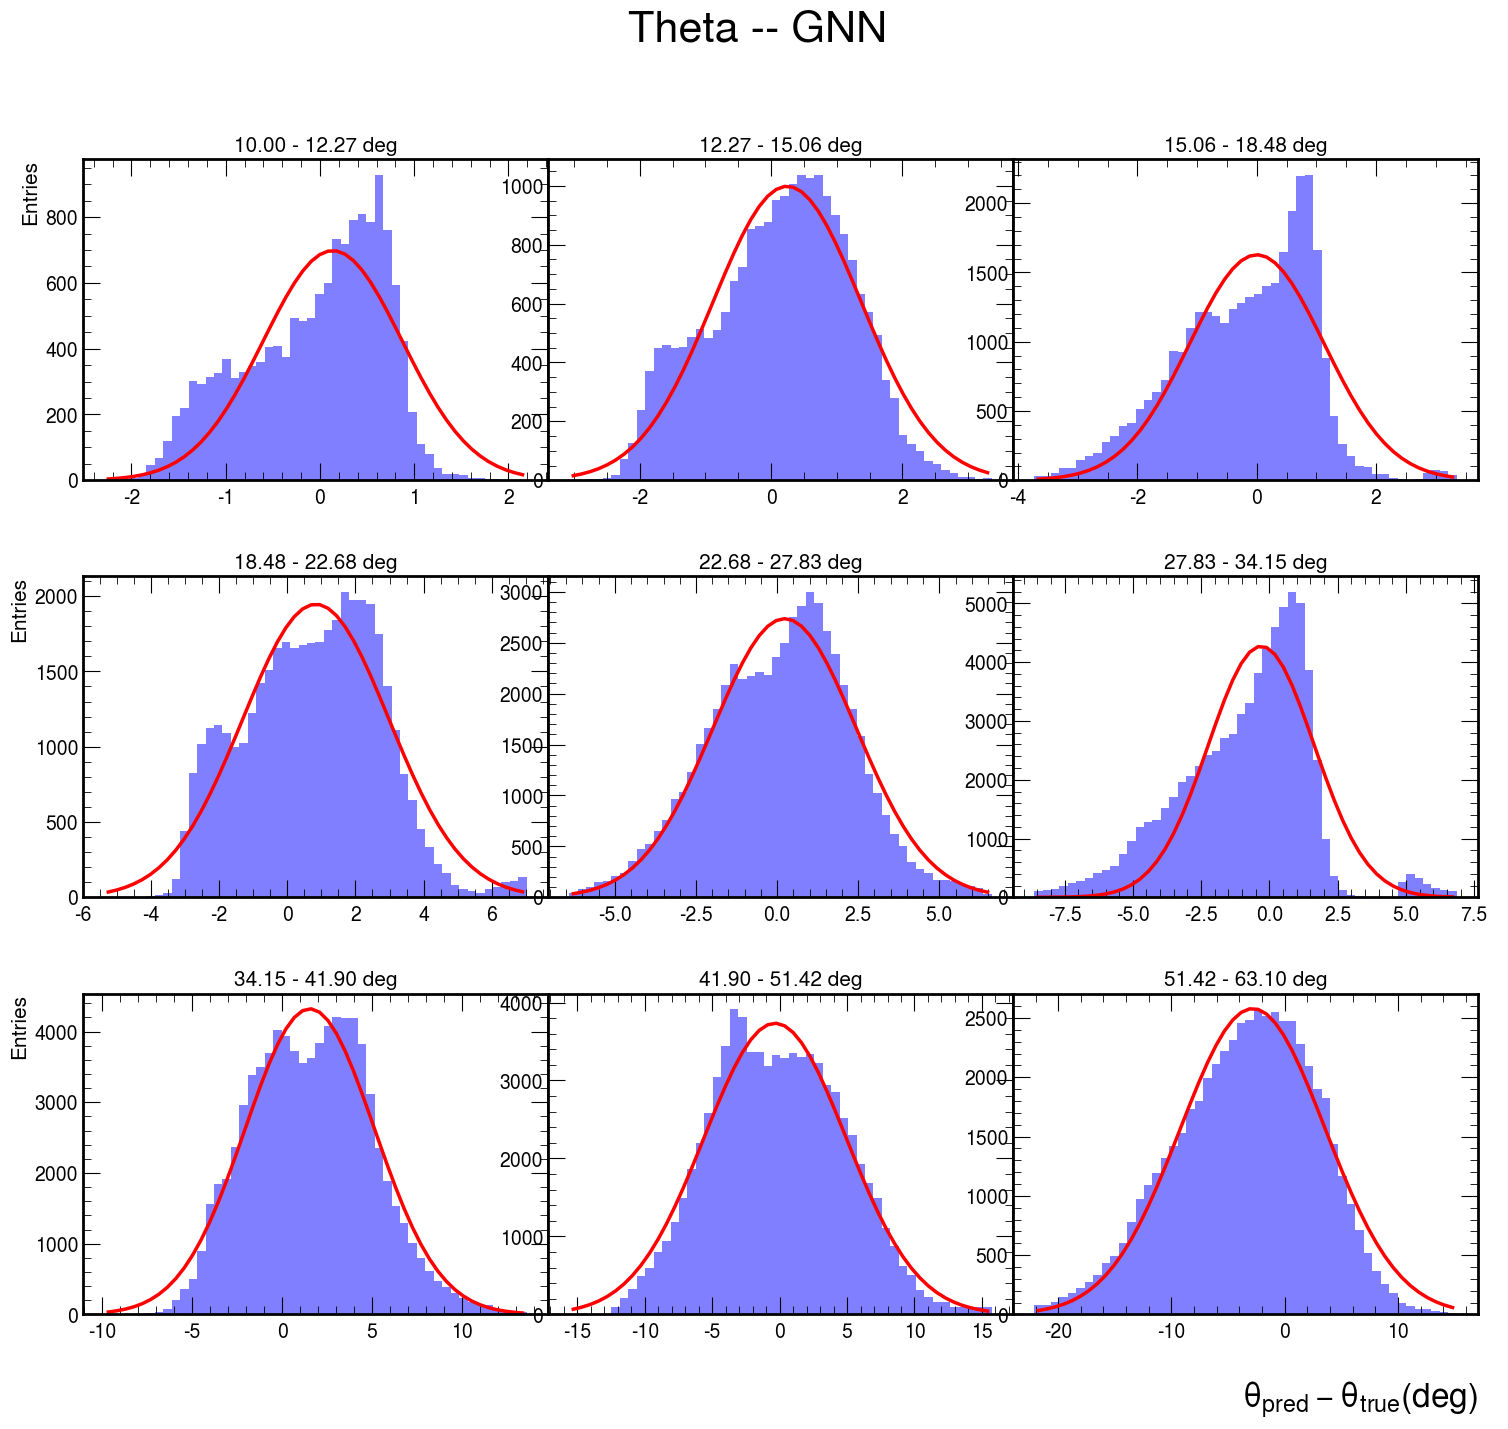

In [19]:
theta_predicted_truth_difference = ak.flatten(predictions_theta) - targets_theta
theta_bin_centers, theta_sigma, theta_mean = get_theta_resolutions(
    theta_predicted_truth_difference,
    targets_theta,
    theta_bins,
    nbins = 50,
    data_name = "theta",
    title="Theta -- GNN",
    units="deg"
)

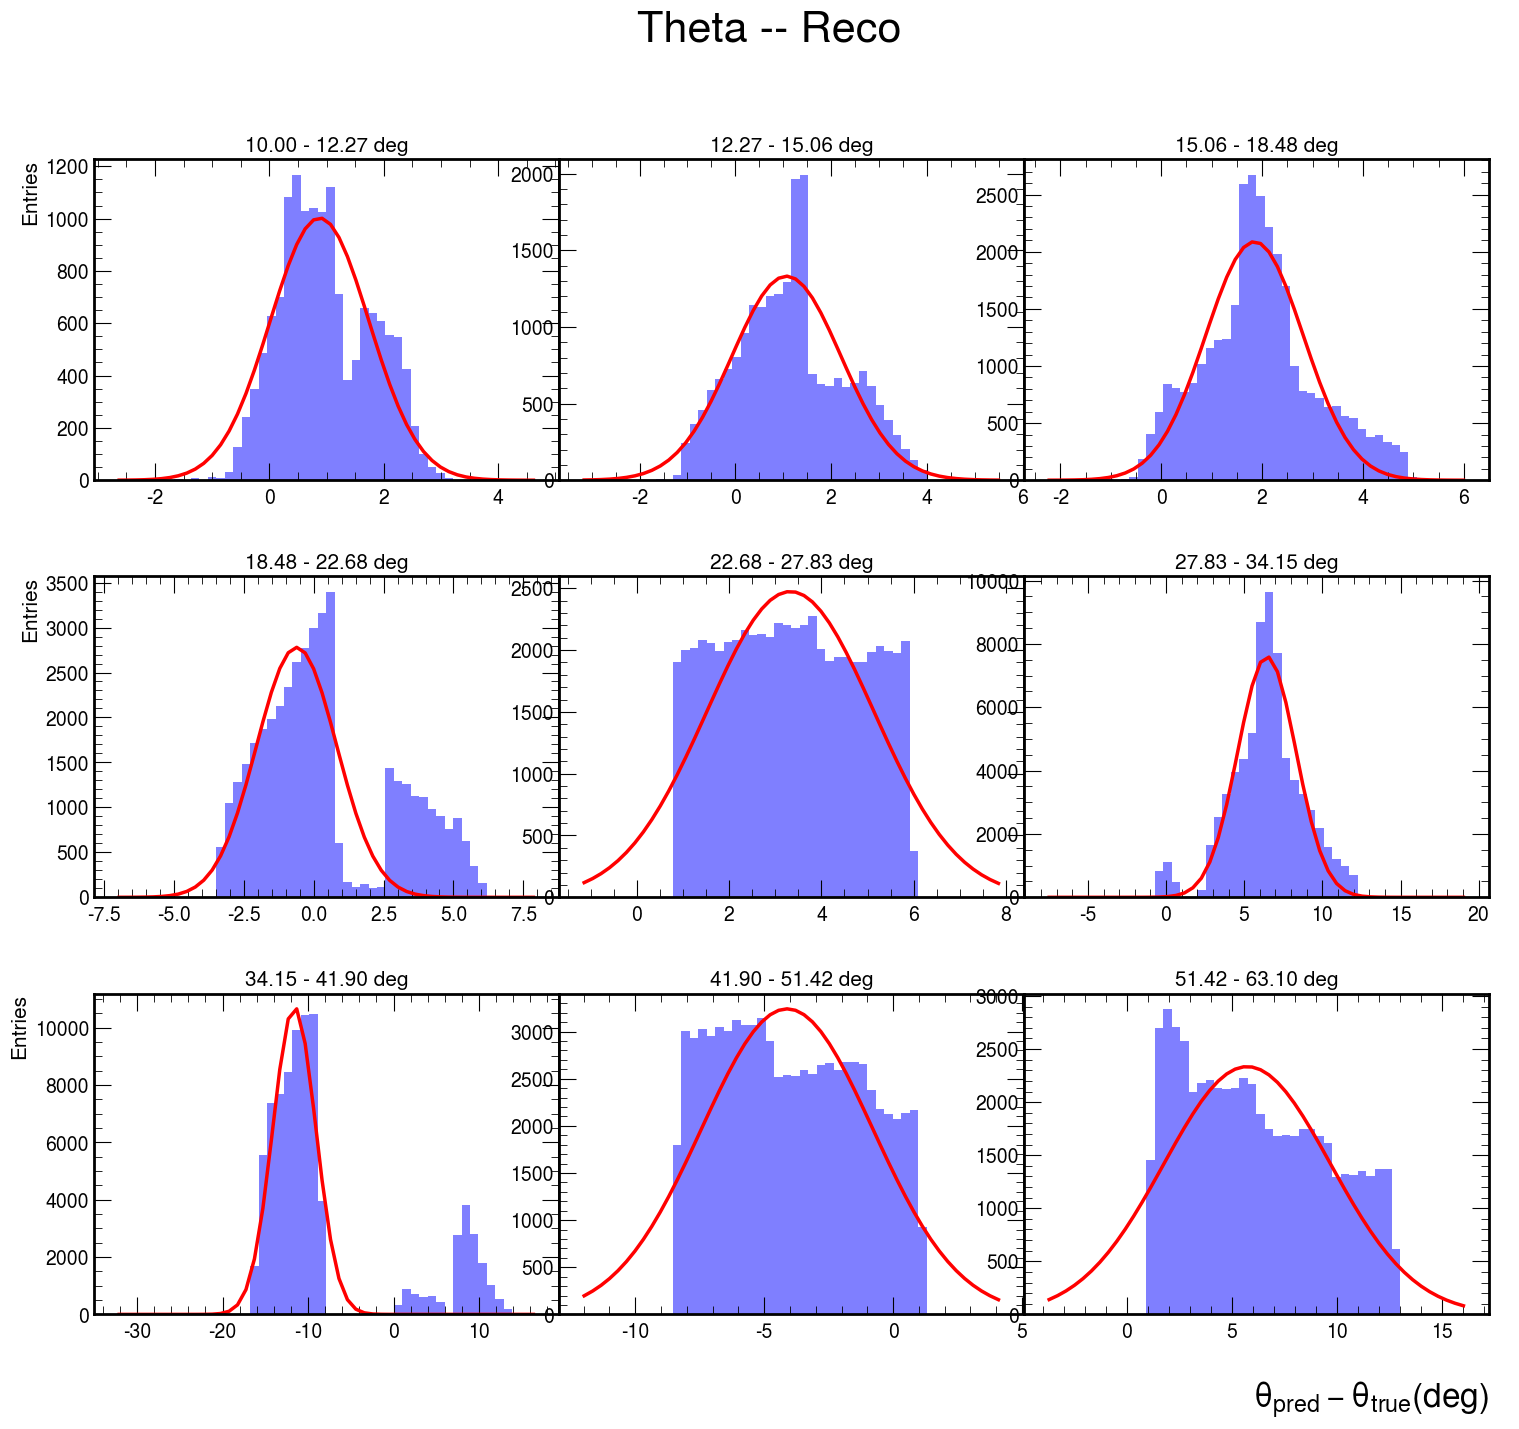

In [20]:
theta_reco_predicted_truth_difference = truth_theta - reco_theta
theta_reco_bin_centers, theta_reco_sigma, theta_reco_mean = get_theta_resolutions(
    theta_reco_predicted_truth_difference,
    truth_theta,
    theta_bins,
    nbins = 50,
    data_name = "theta",
    title="Theta -- Reco",
    units="deg"
)

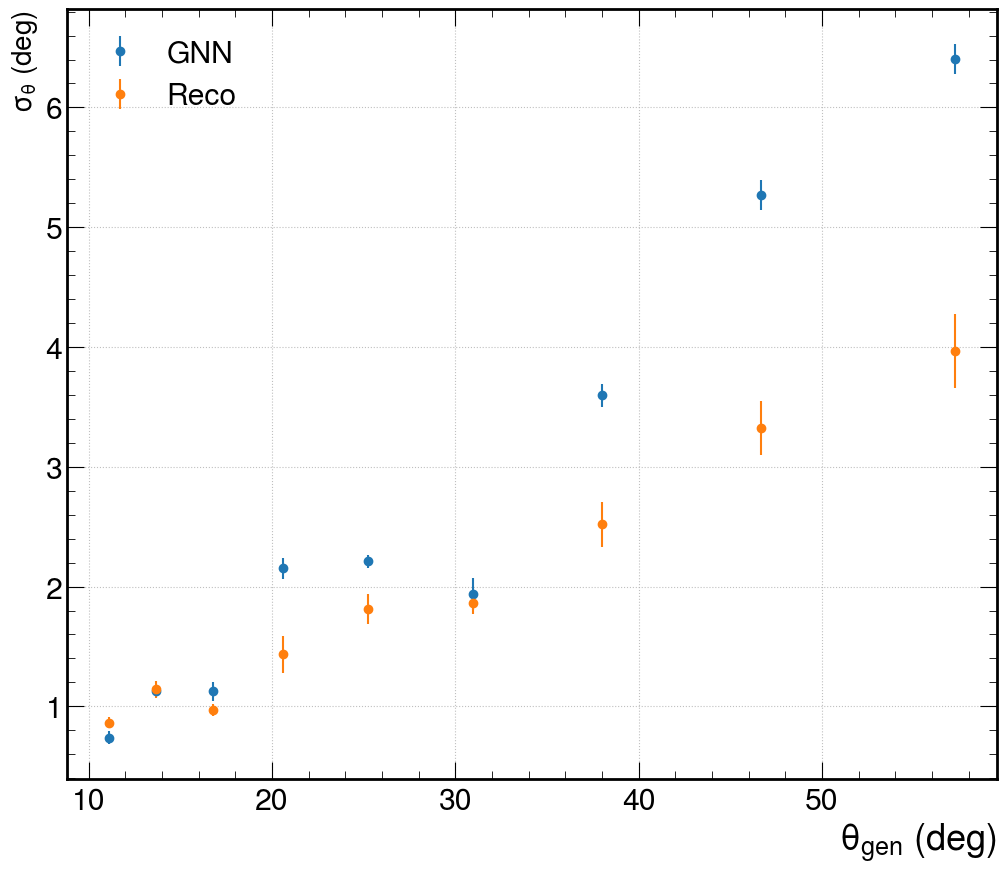

In [21]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

plt.errorbar(
    theta_bin_centers,
    theta_sigma[0],
    yerr = theta_sigma[1],
    marker='o',
    linestyle='none',
    label="GNN",
)
plt.errorbar(
    theta_reco_bin_centers,
    theta_reco_sigma[0],
    yerr = theta_reco_sigma[1],
    marker='o',
    linestyle='none',
    label="Reco",
)  

plt.ylabel("$\sigma_{\\theta}$ (deg)",  fontsize=20)
plt.xlabel("$\\theta_{gen}$ (deg)")
# plt.ylim(0, .45)
plt.grid()
plt.legend()

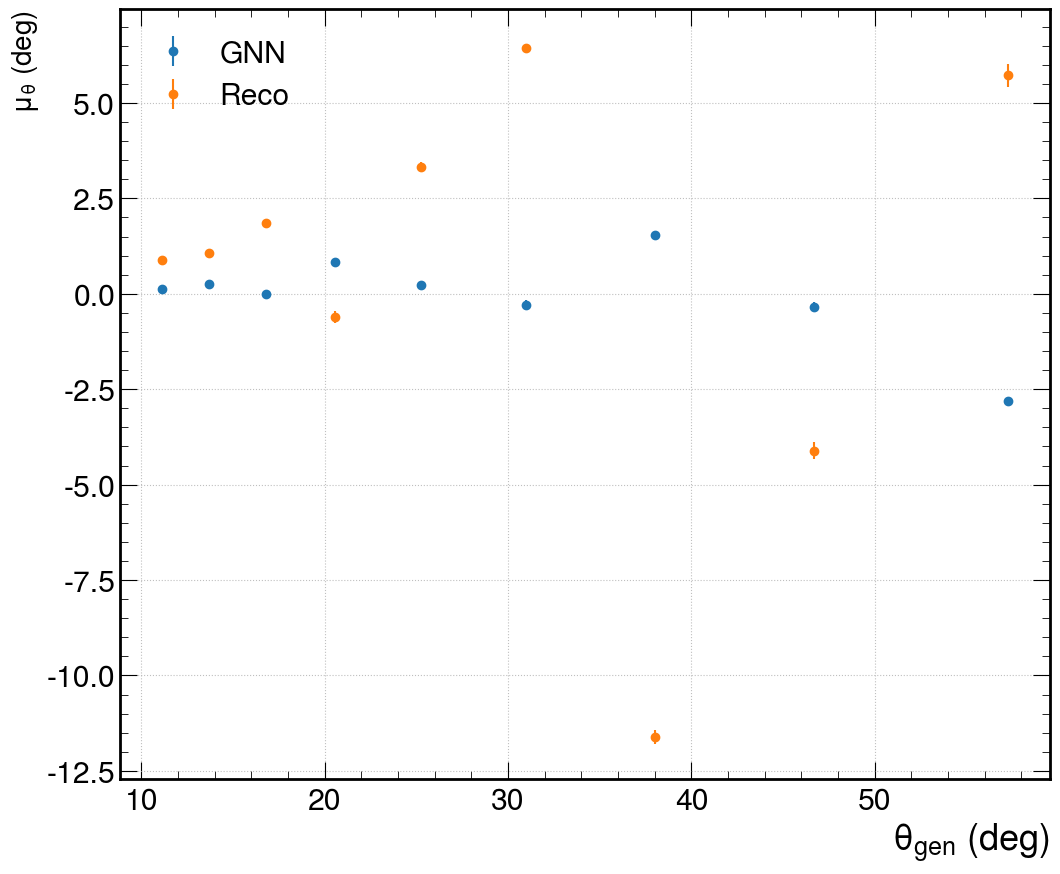

In [22]:
fig = plt.figure(figsize=(12,10))
fig.set_facecolor('w')

plt.errorbar(
    theta_bin_centers,
    theta_mean[0],
    yerr = theta_mean[1],
    marker='o',
    linestyle='none',
    label="GNN",
)

plt.errorbar(
    theta_bin_centers,
    theta_reco_mean[0],
    yerr = theta_reco_mean[1],
    marker='o',
    linestyle='none',
    label="Reco",
)

plt.ylabel("$\mu_{\\theta}$ (deg)",  fontsize=20)
plt.xlabel("$\\theta_{gen}$ (deg)")
# plt.ylim(0, .45)
plt.grid()
plt.legend()